# 2.4 Random Forest - Valentia

#### 1. Import libraries
#### 2. Load data
#### 3. Wrangle data
#### 4. Creates Random Forest model
#### 5. Feature importances

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import os
import operator
import time
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn import datasets
from sklearn.ensemble import RandomForestClassifier
from numpy import argmax
from sklearn import metrics
from sklearn.tree import plot_tree
from sklearn import tree
from sklearn.model_selection import GridSearchCV
from scipy.stats import randint
from sklearn.model_selection import RandomizedSearchCV

#### 2. Load data

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
X=pd.read_csv('/content/drive/MyDrive/7 Machine Learning/Notebooks/Dataset-weather-cleaned.csv')

In [4]:
X.head()

,BASEL_cloud_cover,BASEL_humidity,BASEL_pressure,BASEL_global_radiation,BASEL_precipitation,BASEL_sunshine,BASEL_temp_mean,BASEL_temp_min,BASEL_temp_max,BELGRADE_cloud_cover,...,STOCKHOLM_temp_max,VALENTIA_cloud_cover,VALENTIA_humidity,VALENTIA_pressure,VALENTIA_global_radiation,VALENTIA_precipitation,VALENTIA_sunshine,VALENTIA_temp_mean,VALENTIA_temp_min,VALENTIA_temp_max
0,7,0.85,1.018,0.32,0.09,0.7,6.5,0.8,10.9,1,...,4.9,5,0.88,1.0003,0.45,0.34,4.7,8.5,6.0,10.9
1,6,0.84,1.018,0.36,1.05,1.1,6.1,3.3,10.1,6,...,5.0,7,0.91,1.0007,0.25,0.84,0.7,8.9,5.6,12.1
2,8,0.90,1.018,0.18,0.30,0.0,8.5,5.1,9.9,6,...,4.1,7,0.91,1.0096,0.17,0.08,0.1,10.5,8.1,12.9
3,3,0.92,1.018,0.58,0.00,4.1,6.3,3.8,10.6,8,...,2.3,7,0.86,1.0184,0.13,0.98,0.0,7.4,7.3,10.6
4,6,0.95,1.018,0.65,0.14,5.4,3.0,-0.7,6.0,8,...,4.3,3,0.80,1.0328,0.46,0.00,5.7,5.7,3.0,8.4


In [5]:
X.shape

(22950, 135)

In [6]:
dfa=pd.read_csv(('/content/drive/MyDrive/7 Machine Learning/Notebooks/climate_answers.csv'), index_col=0)

In [7]:
dfa.head()

,BASEL_pleasant_weather,BELGRADE_pleasant_weather,BUDAPEST_pleasant_weather,DEBILT_pleasant_weather,DUSSELDORF_pleasant_weather,HEATHROW_pleasant_weather,KASSEL_pleasant_weather,LJUBLJANA_pleasant_weather,MAASTRICHT_pleasant_weather,MADRID_pleasant_weather,MUNCHENB_pleasant_weather,OSLO_pleasant_weather,SONNBLICK_pleasant_weather,STOCKHOLM_pleasant_weather,VALENTIA_pleasant_weather
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [8]:
dfa.shape

(22950, 15)

#### 3. Wrangle data

In [9]:
# Create a list of the columns containing "Valentia" in their names

valentia_list = list(x for x in X.columns if x.find('VALENTIA') >=0)
valentia_list

['VALENTIA_cloud_cover',
 'VALENTIA_humidity',
 'VALENTIA_pressure',
 'VALENTIA_global_radiation',
 'VALENTIA_precipitation',
 'VALENTIA_sunshine',
 'VALENTIA_temp_mean',
 'VALENTIA_temp_min',
 'VALENTIA_temp_max']

In [10]:
# Create a dataframe with those columns

df_valentia = X[valentia_list]
df_valentia

,VALENTIA_cloud_cover,VALENTIA_humidity,VALENTIA_pressure,VALENTIA_global_radiation,VALENTIA_precipitation,VALENTIA_sunshine,VALENTIA_temp_mean,VALENTIA_temp_min,VALENTIA_temp_max
0,5,0.88,1.0003,0.45,0.34,4.7,8.5,6.0,10.9
1,7,0.91,1.0007,0.25,0.84,0.7,8.9,5.6,12.1
2,7,0.91,1.0096,0.17,0.08,0.1,10.5,8.1,12.9
3,7,0.86,1.0184,0.13,0.98,0.0,7.4,7.3,10.6
4,3,0.80,1.0328,0.46,0.00,5.7,5.7,3.0,8.4
...,...,...,...,...,...,...,...,...,...
22945,5,0.82,1.0142,1.13,0.41,3.4,10.7,7.9,13.5
22946,5,0.82,1.0142,1.13,0.41,3.4,10.7,7.9,13.5
22947,5,0.82,1.0142,1.13,0.41,3.4,10.7,7.9,13.5
22948,5,0.82,1.0142,1.13,0.41,3.4,10.7,7.9,13.5


In [11]:
# Reduce answers dataset to Valentia's answers only

answers_valentia = dfa['VALENTIA_pleasant_weather']
answers_valentia

,VALENTIA_pleasant_weather
0,0
1,0
2,0
3,0
4,0
...,...
22945,0
22946,0
22947,0
22948,0


In [12]:
# make into X and y data sets

X2 = df_valentia
y2 = answers_valentia

In [13]:
# Turn X2 and y2 from df to arrays

X = np.array(X2)
y = np.array(y2)

In [14]:
X.shape

(22950, 9)

In [15]:
y.shape

(22950,)

In [16]:
from sklearn.model_selection import train_test_split

In [17]:
# Split data into train and test sets

X_train, X_test, y_train, y_test = train_test_split(X,y,random_state = 42)

In [18]:
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(17212, 9) (17212,)
(5738, 9) (5738,)


In [19]:
len(X_train[0])

9

#### 4. Random Search

In [20]:
# Random search cv
rs_space={'max_depth':list(np.arange(10, 100, step=10)) + [None],
              'n_estimators':np.arange(10, 500, step=50),
              'max_features':randint(1,7),
              'criterion':['gini','entropy'],
              'min_samples_leaf':randint(1,4),
              'min_samples_split':np.arange(2, 10, step=2)
}

In [21]:
# creating a RF classifier
clf2= RandomForestClassifier()

In [23]:
start = time.time()
rf_random = RandomizedSearchCV(clf2, rs_space, n_iter=50, scoring='accuracy', verbose=3, n_jobs=-1, cv=3) #500
model_random = rf_random.fit(X_train, y_train)
print('Search took %s minutes' % ((time.time() - start)/60))

Fitting 3 folds for each of 50 candidates, totalling 150 fits
Search took 4.105688711007436 minutes


In [24]:
# random random search results
print('Best RANDOM search hyperparameters are: '+str(model_random.best_params_))
print('Best RANDOM search score is: '+str(model_random.best_score_))

Best RANDOM search hyperparameters are: {'criterion': 'gini', 'max_depth': None, 'max_features': 3, 'min_samples_leaf': 3, 'min_samples_split': np.int64(2), 'n_estimators': np.int64(260)}
Best RANDOM search score is: 1.0


#### 5. Performing predictions on test data set

In [27]:
# creating a RF classifier with the best results from above
clf3 = RandomForestClassifier(n_estimators = 260, max_depth=None, max_features=3, min_samples_leaf=3, min_samples_split=2, criterion = 'gini')

# Training the model on the training dataset
# fit function is used to train the model using the training sets as parameters
clf3.fit(X_train, y_train)

RandomForestClassifier(max_features=3, min_samples_leaf=3, n_estimators=260)

In [28]:
# performing predictions on the test dataset
y_pred = clf3.predict(X_test)

# using metrics module for accuracy calculation
print("Model Accuracy: ", metrics.accuracy_score(y_test, y_pred))

Model Accuracy:  1.0


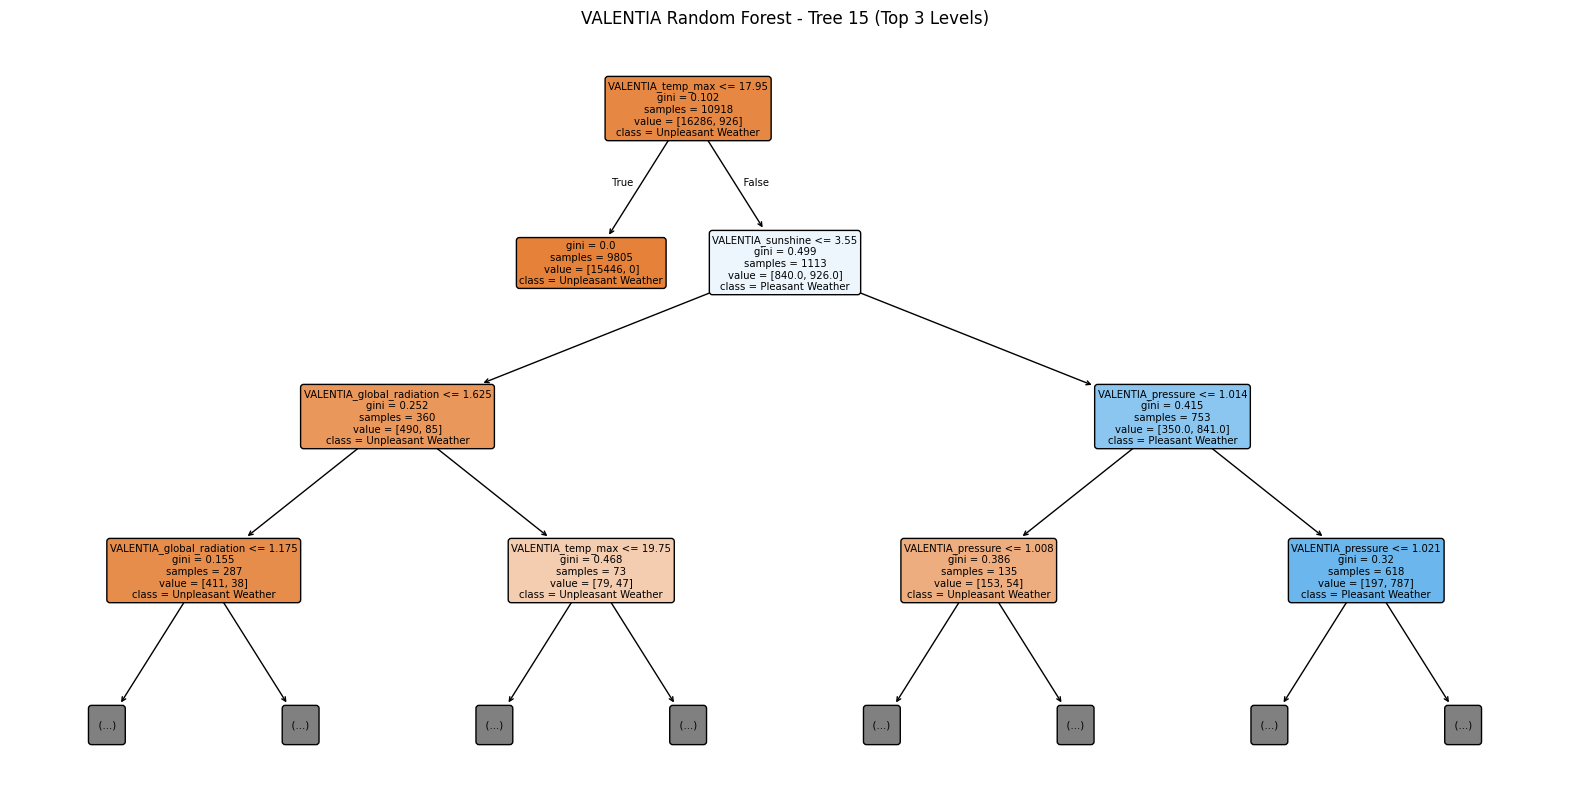

In [30]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Plot the 15th tree from the VALENTIA model
plt.figure(figsize=(20, 10))
plot_tree(
    clf3.estimators_[15],
    feature_names=df_valentia.columns,
    class_names=["Unpleasant Weather", "Pleasant Weather"],
    filled=True,
    rounded=True,
    max_depth=3                      # Show just top 3 levels to keep it readable
)
plt.title("VALENTIA Random Forest - Tree 15 (Top 3 Levels)")
plt.show()

#### 6. Feature importances

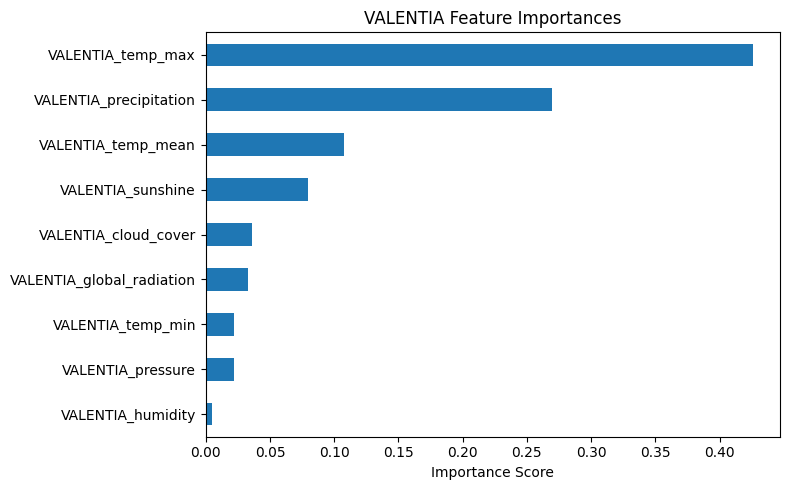

In [31]:
# Create a Series for VALENTIA feature importances
importances_valentia = pd.Series(clf3.feature_importances_, index=df_valentia.columns)

# Plot top features (all 9 in this case)
importances_valentia.sort_values(ascending=False).plot(kind='barh', figsize=(8, 5))
plt.title("VALENTIA Feature Importances")
plt.xlabel("Importance Score")
plt.gca().invert_yaxis()  # Show most important at the top
plt.tight_layout()
plt.show()

#### 7. Interested to try more iterations

In [32]:
# creating a RF classifier
clf4= RandomForestClassifier()

In [33]:
start = time.time()
rf_random = RandomizedSearchCV(clf4, rs_space, n_iter=100, scoring='accuracy', verbose=3, n_jobs=-1, cv=3) #500
model_random = rf_random.fit(X_train, y_train)
print('Search took %s minutes' % ((time.time() - start)/60))

Fitting 3 folds for each of 100 candidates, totalling 300 fits
Search took 7.102357228597005 minutes


In [34]:
# random random search results
print('Best RANDOM search hyperparameters are: '+str(model_random.best_params_))
print('Best RANDOM search score is: '+str(model_random.best_score_))

Best RANDOM search hyperparameters are: {'criterion': 'entropy', 'max_depth': np.int64(50), 'max_features': 5, 'min_samples_leaf': 3, 'min_samples_split': np.int64(8), 'n_estimators': np.int64(460)}
Best RANDOM search score is: 1.0


#### 8. Performing predictions on training data set

In [36]:
# creating a RF classifier with the best results from above
clf5 = RandomForestClassifier(n_estimators = 460, max_depth=50, max_features=5, min_samples_leaf=3, min_samples_split=8, criterion = 'entropy')

# Training the model on the training dataset
# fit function is used to train the model using the training sets as parameters
clf5.fit(X_train, y_train)

RandomForestClassifier(criterion='entropy', max_depth=50, max_features=5,
                       min_samples_leaf=3, min_samples_split=8,
                       n_estimators=460)

In [38]:
# performing predictions on the test dataset
y_pred = clf5.predict(X_test)

# using metrics module for accuracy calculation
print("Model Accuracy: ", metrics.accuracy_score(y_test, y_pred))

Model Accuracy:  1.0


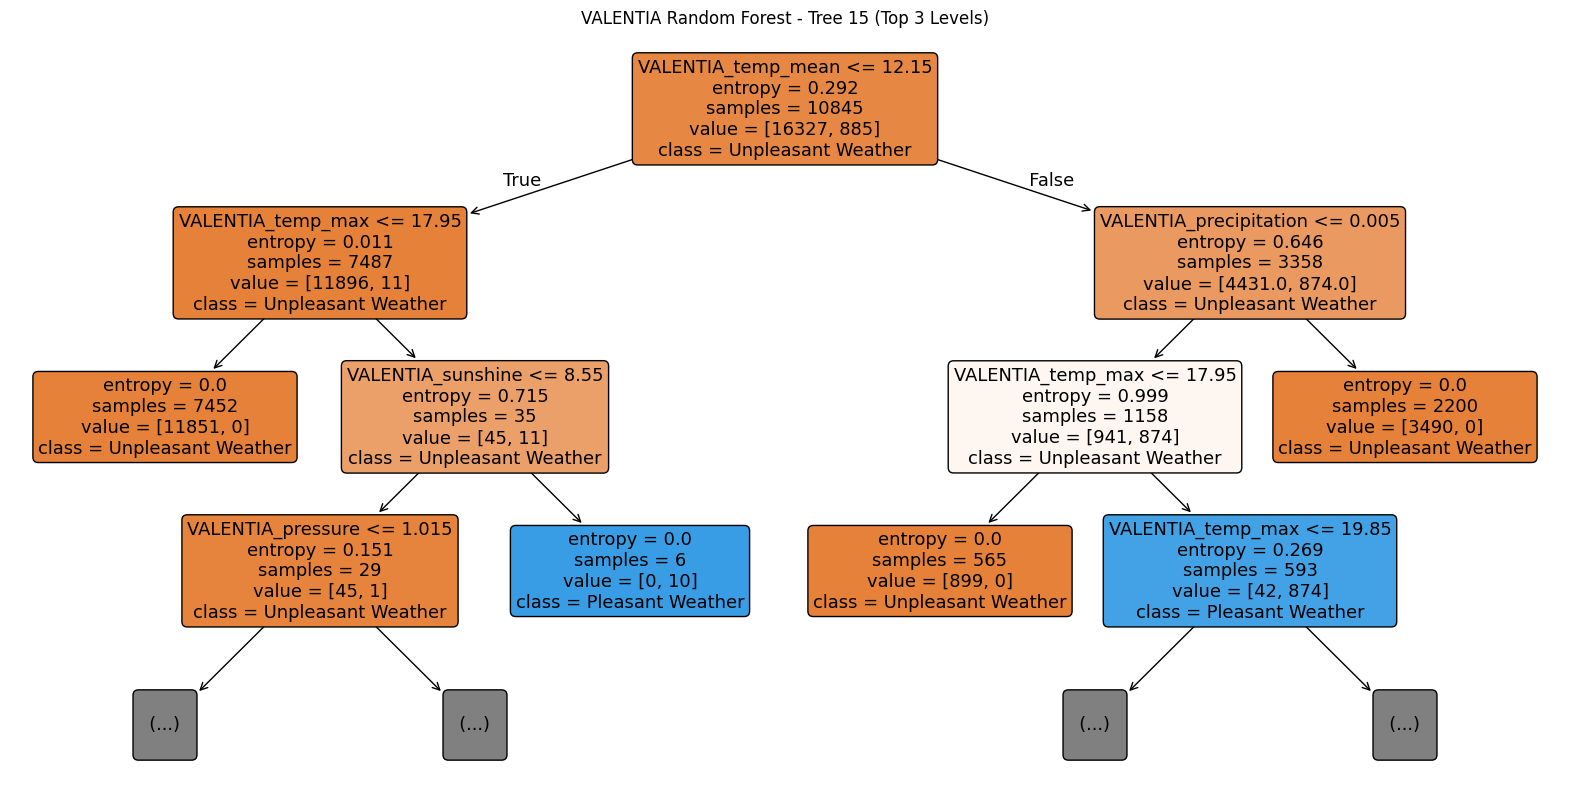

In [39]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Plot the 15th tree from the VALENTIA model
plt.figure(figsize=(20, 10))
plot_tree(
    clf5.estimators_[15],
    feature_names=df_valentia.columns,
    class_names=["Unpleasant Weather", "Pleasant Weather"],
    filled=True,
    rounded=True,
    max_depth=3                      # Show just top 3 levels to keep it readable
)
plt.title("VALENTIA Random Forest - Tree 15 (Top 3 Levels)")
plt.show()

#### 9. Feature importances

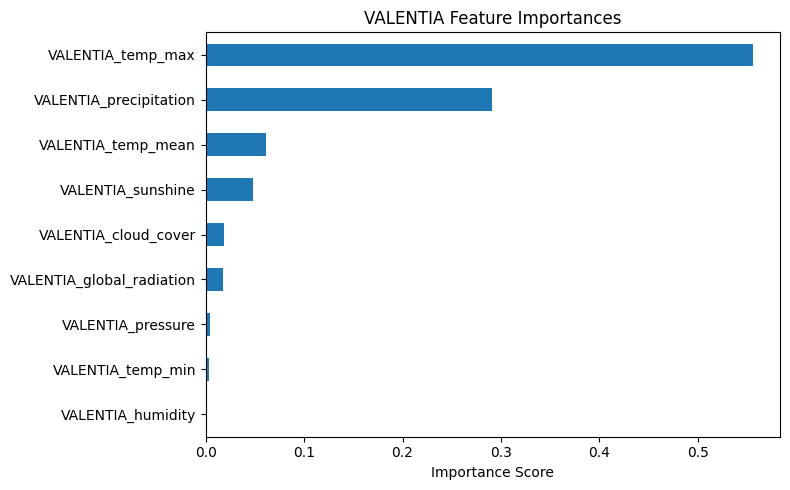

In [41]:
# Create a Series for VALENTIA feature importances
importances_valentia = pd.Series(clf5.feature_importances_, index=df_valentia.columns)

# Plot top features (all 9 in this case)
importances_valentia.sort_values(ascending=False).plot(kind='barh', figsize=(8, 5))
plt.title("VALENTIA Feature Importances")
plt.xlabel("Importance Score")
plt.gca().invert_yaxis()  # Show most important at the top
plt.tight_layout()
plt.show()